# 0. Import library

In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "1"  # 물리적 2번 GPU만 보이게 설정

import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Current device: {device}")
# 이제 torch.cuda.get_device_name(0)을 하면 물리적 2번 GPU의 이름이 나옵니다.

Current device: cuda


In [2]:
import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset


import numpy as np
from tqdm import tqdm
import pickle
import seaborn as sns
import matplotlib.pyplot as plt
import time
import copy
from moving_average import moving_average_1d

import importlib
import policy
importlib.reload(policy)
from policy import PolicyNN

from nn_functions import surrogate

import sys
sys.path.append('../1_model')
from TiDE import TideModule, quantile_loss  


# 1-1. Import Data 

In [3]:
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')
print(df_all.shape)
print(df_all.columns)

nan_rows = df_all[df_all.isna().any(axis=1)]

df_all = df_all.dropna()

loc_X = df_all["X"].to_numpy().reshape(-1,1)
loc_Y = df_all["Y"].to_numpy().reshape(-1,1)
loc_Z = df_all["Z"].to_numpy().reshape(-1,1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1,1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1,1)
# dist_Z = df_all["Dist_to_nearest_Z"].to_numpy()[::2].reshape(-1,1)
scan_spd = df_all["scanning_speed"].to_numpy().reshape(-1,1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1,1)
laser_on_off = df_all["laser_power_number"].to_numpy().reshape(-1,1)

# apply moving average for mp temp
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw,4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1,1)

# apply moving average for mp depth
mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw,4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1,1)       


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


## 1-2. Normalize data

In [4]:
# stack input array
x_original_scale = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)
y_original_scale = np.concatenate((mp_temp, mp_depth), axis=1)

# scaling
x_max = np.max(x_original_scale,0).reshape(1,-1)
x_min = np.min(x_original_scale,0).reshape(1,-1) 
y_max = np.max(y_original_scale,0).reshape(1,-1) 
y_min = np.min(y_original_scale,0).reshape(1,-1)

print("x_max:", np.round(x_max, 3).tolist())
print("x_min:", np.round(x_min, 3).tolist())
print("y_max:", np.round(y_max, 3).tolist())
print("y_min:", np.round(y_min, 3).tolist())

x_max: [[7.5, 20.0, 20.0, 732.298]]
x_min: [[0.0, 0.75, 0.75, 504.26]]
y_max: [[4509.855, 0.551]]
y_min: [[436.608, -0.559]]


In [5]:
class scalers():
    def __init__(self,x_max, x_min, y_max, y_min) -> None:
        self.x_max = x_max
        self.x_min = x_min
        self.y_max = y_max
        self.y_min = y_min
        
        return None
    
    def scaler_x(self, x_original, dim_id = -1):
        if dim_id == -1:
            x_s = -1 + 2 * ((x_original - self.x_min) / (self.x_max-self.x_min))
            return x_s
        else: 
            x_s = -1 + 2 * (x_original - self.x_min[0,dim_id]) / (self.x_max[0,dim_id] - self.x_min[0,dim_id])
            return x_s
    
    def inv_scaler_x(self, x_s, dim_id = -1):
        
        if dim_id == -1:
            x_original = (x_s + 1)*0.5*(self.x_max-self.x_min) + self.x_min
            return x_original
        else: 
            x_original = (x_s + 1)*0.5*(self.x_max[0,dim_id] - self.x_min[0,dim_id]) + self.x_min[0,dim_id]
            return x_original
        
    def scaler_y(self, y_original):
        return -1 + 2 * ((y_original - self.y_min) / (self.y_max-self.y_min))
    
    def inv_scaler_y(self, y_s):
        return (y_s + 1)*0.5*(self.y_max-self.y_min) + self.y_min

In [6]:
scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original_scale)
y_s = scaler.scaler_y(y_original_scale)

print("x_s range:", np.min(x_s), "to", np.max(x_s))
print("y_s range:", np.min(y_s), "to", np.max(y_s))

print("x_s shape:", x_s.shape)
print("y_s shape:", y_s.shape)

x_s range: -1.0 to 1.0
y_s range: -1.0 to 1.0
x_s shape: (610417, 4)
y_s shape: (610417, 2)


## 1-3. Generate data

In [7]:
length = y_s.shape[0]

y_s_ref = np.random.uniform(0.0, 1.0, size=(length, 1))

e = 0.0001
y_depth_low = np.random.uniform(0.1423-e, 0.1423+e, size = (length,1))
y_depth_up = np.random.uniform(0.4126-e, 0.4126+e, size = (length,1))
# constraints!
#y_depth_low = 0*np.random.uniform(0.0, 0.5, size=(length, 1))
#y_depth_up = 0*np.random.uniform(0.5, 1.0, size=(length, 1))

y_s_const = np.concatenate((y_depth_low, y_depth_up), axis=1)

print("y_s_ref shape:", y_s_ref.shape)
print("y_s_const shape:", y_s_const.shape)

y_s_ref shape: (610417, 1)
y_s_const shape: (610417, 2)


## 1-4. Split data

In [8]:
import numpy as np
import pandas as pd
import torch
import copy
from tqdm import tqdm

# =====================================================
# 1. Load & preprocess raw data
# =====================================================
df_all = pd.read_csv('../0_data/merged_df_2_99_temp_depth.csv')

print(df_all.shape)
print(df_all.columns)

# ---- global time index (핵심) ----
df_all = df_all.reset_index(drop=True)
df_all["time_id"] = np.arange(len(df_all))

# ---- NaN handling (time_id 유지) ----
nan_rows = df_all[df_all.isna().any(axis=1)]
df_all = df_all.dropna().reset_index(drop=True)

# =====================================================
# 2. Feature extraction
# =====================================================
loc_Z = df_all["Z"].to_numpy().reshape(-1, 1)
dist_X = df_all["Dist_to_nearest_X"].to_numpy().reshape(-1, 1)
dist_Y = df_all["Dist_to_nearest_Y"].to_numpy().reshape(-1, 1)
laser_power = df_all["Laser_power"].to_numpy().reshape(-1, 1)

# ---- global time id ----
time_id_all = df_all["time_id"].to_numpy()

# =====================================================
# 3. Melt pool smoothing
# =====================================================
mp_temp_raw = df_all["melt_pool_temperature"].to_numpy()
mp_temp_mv = moving_average_1d(mp_temp_raw, 4)
mp_temp = copy.deepcopy(mp_temp_raw)
mp_temp[1:-2] = mp_temp_mv
mp_temp = mp_temp.reshape(-1, 1)

mp_depth_raw = df_all["melt_pool_depth"].to_numpy()
mp_depth_mv = moving_average_1d(mp_depth_raw, 4)
mp_depth = copy.deepcopy(mp_depth_raw)
mp_depth[1:-2] = mp_depth_mv
mp_depth = mp_depth.reshape(-1, 1)

# =====================================================
# 4. Stack original-scale arrays
# =====================================================
x_original = np.concatenate((loc_Z, dist_X, dist_Y, laser_power), axis=1)  # (N,4)
y_original = np.concatenate((mp_temp, mp_depth), axis=1)                  # (N,2)

# =====================================================
# 5. Scaling (-1 ~ 1)
# =====================================================
x_max = np.max(x_original, axis=0, keepdims=True)
x_min = np.min(x_original, axis=0, keepdims=True)
y_max = np.max(y_original, axis=0, keepdims=True)
y_min = np.min(y_original, axis=0, keepdims=True)

scaler = scalers(x_max, x_min, y_max, y_min)

x_s = scaler.scaler_x(x_original)
y_s = scaler.scaler_y(y_original)

# =====================================================
# 6. Reference / Constraint (global arrays)
# =====================================================
length = y_s.shape[0]

# =====================================================
# Global reference (temperature)
# =====================================================
y_ref_global = y_s[:, 0:1]   # (N, 1)


# depth constraint (global)
e = 1e-4
y_depth_low = np.random.uniform(0.1423 - e, 0.1423 + e, size=(length, 1))
y_depth_up  = np.random.uniform(0.4126 - e, 0.4126 + e, size=(length, 1))
y_const_global = np.concatenate((y_depth_low, y_depth_up), axis=1)  # (N,2)

# =====================================================
# 7. Train / Validation split (time-consistent)
# =====================================================
cutoff_index = int(np.round(0.8 * length))

x_train, y_train = x_s[:cutoff_index], y_s[:cutoff_index]
x_val,   y_val   = x_s[cutoff_index:], y_s[cutoff_index:]

time_id_train = time_id_all[:cutoff_index]
time_id_val   = time_id_all[cutoff_index:]

# =====================================================
# 7. (삭제/변경) Train/Val split을 먼저 하지 말고
#    8번에서 전체 샘플을 먼저 만든 뒤 shuffle split
# =====================================================

window = 50
P = 50
N = length

# 전체에서 만들 수 있는 샘플 개수
# i는 "현재 시점(start of future)" 인덱스
# i는 [window, N-P) 범위
n_all = (N - P) - window

x_past_all = np.empty((n_all, window, 4))
y_past_all = np.empty((n_all, window, 2))
x_future_all = np.empty((n_all, P, 3))
y_ref_all_seq = np.empty((n_all, P, 1))
y_const_all_seq = np.empty((n_all, P, 2))
time_idx_all_seq = np.empty(n_all, dtype=np.int64)

for i in tqdm(range(window, N - P)):
    j = i - window

    x_past_all[j] = x_s[i-window:i]
    y_past_all[j] = y_s[i-window:i]
    x_future_all[j] = x_s[i:i+P, :3]

    # reference
    scalar_shift = 0
    y_ref_all_seq[j] = y_ref_global[i:i+P] + scalar_shift

    # constraint
    y_const_all_seq[j] = y_const_global[i:i+P]

    # time index (글로벌)
    time_idx_all_seq[j] = time_id_all[i]

# =====================================================
# 8. Shuffle 후 8:2 split (샘플 단위)
# =====================================================
rng = np.random.default_rng(42)  # 재현성
perm = rng.permutation(n_all)

cut = int(np.round(0.8 * n_all))
train_idx = perm[:cut]
val_idx   = perm[cut:]

x_past_train = x_past_all[train_idx]
y_past_train = y_past_all[train_idx]
x_future_train = x_future_all[train_idx]
y_ref_train_seq = y_ref_all_seq[train_idx]
y_const_train_seq = y_const_all_seq[train_idx]
time_idx_train = time_idx_all_seq[train_idx]

x_past_val = x_past_all[val_idx]
y_past_val = y_past_all[val_idx]
x_future_val = x_future_all[val_idx]
y_ref_val_seq = y_ref_all_seq[val_idx]
y_const_val_seq = y_const_all_seq[val_idx]
time_idx_val = time_idx_all_seq[val_idx]

# =====================================================
# 9. Torch tensor conversion
# =====================================================
x_past_train = torch.tensor(x_past_train, dtype=torch.float32)
y_past_train = torch.tensor(y_past_train, dtype=torch.float32)
x_future_train = torch.tensor(x_future_train, dtype=torch.float32)
y_ref_train_seq = torch.tensor(y_ref_train_seq, dtype=torch.float32)
y_const_train_seq = torch.tensor(y_const_train_seq, dtype=torch.float32)
time_idx_train = torch.tensor(time_idx_train, dtype=torch.long)

x_past_val = torch.tensor(x_past_val, dtype=torch.float32)
y_past_val = torch.tensor(y_past_val, dtype=torch.float32)
x_future_val = torch.tensor(x_future_val, dtype=torch.float32)
y_ref_val_seq = torch.tensor(y_ref_val_seq, dtype=torch.float32)
y_const_val_seq = torch.tensor(y_const_val_seq, dtype=torch.float32)
time_idx_val = torch.tensor(time_idx_val, dtype=torch.long)


# =====================================================
# 10. Shape check
# =====================================================
print("Train shapes:")
print("x_past:", x_past_train.shape)
print("y_past:", y_past_train.shape)
print("x_future:", x_future_train.shape)
print("y_ref:", y_ref_train_seq.shape)
print("y_const:", y_const_train_seq.shape)
print("time_idx:", time_idx_train.shape)

print("\nVal shapes:")
print("x_past:", x_past_val.shape)
print("y_past:", y_past_val.shape)
print("x_future:", x_future_val.shape)
print("y_ref:", y_ref_val_seq.shape)
print("y_const:", y_const_val_seq.shape)
print("time_idx:", time_idx_val.shape)


(610615, 12)
Index(['time_index', 'melt_pool_temperature', 'melt_pool_depth',
       'scanning_speed', 'X', 'Y', 'Z', 'Dist_to_nearest_X',
       'Dist_to_nearest_Y', 'Dist_to_nearest_Z', 'Laser_power',
       'laser_power_number'],
      dtype='object')


100%|██████████| 610317/610317 [00:03<00:00, 173635.23it/s]


Train shapes:
x_past: torch.Size([488254, 50, 4])
y_past: torch.Size([488254, 50, 2])
x_future: torch.Size([488254, 50, 3])
y_ref: torch.Size([488254, 50, 1])
y_const: torch.Size([488254, 50, 2])
time_idx: torch.Size([488254])

Val shapes:
x_past: torch.Size([122063, 50, 4])
y_past: torch.Size([122063, 50, 2])
x_future: torch.Size([122063, 50, 3])
y_ref: torch.Size([122063, 50, 1])
y_const: torch.Size([122063, 50, 2])
time_idx: torch.Size([122063])


In [9]:
batch_size = 256

# ------------------ Training loader ------------------
train_dataset = TensorDataset(
    x_past_train,
    y_past_train,
    x_future_train,
    y_ref_train_seq,
    y_const_train_seq,
    time_idx_train          # ⭐ 반드시 포함
)

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True           # ⭐ 핵심 수정
)

# ------------------ Validation loader ------------------
val_dataset = TensorDataset(
    x_past_val,
    y_past_val,
    x_future_val,
    y_ref_val_seq,
    y_const_val_seq,
    time_idx_val
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)


# 2. Loss function

In [10]:
def DPC_loss(
    x_past: torch.Tensor,
    tide_output: torch.Tensor,
    reference: torch.Tensor,
    u_output: torch.Tensor,
    constraint: torch.Tensor,
    w_tracking=1, w_smooth=1, w_constraint=3
):
    tide_output = tide_output.median(dim=-1).values
    tide_output_temp = tide_output[:, :, 0]
    reference = reference[:, :, 0]
    tracking_loss = (reference - tide_output_temp) ** 2

    T = tracking_loss.shape[1]
    q_weights = torch.linspace(1.0, 1.0, T, device=tracking_loss.device).unsqueeze(0)
    tracking_loss = tracking_loss * q_weights

    u_diff = u_output[:, 1:, :] - u_output[:, :-1, :]
    smoothness_loss = u_diff ** 2

    tide_output_depth = tide_output[:, :, 1]

    low_violation = torch.relu(constraint[:, :, 0] - tide_output_depth) ** 2
    up_violation  = torch.relu(tide_output_depth - constraint[:, :, 1]) ** 2

    # ✅ low-constraint gate: x_past의 1번째 component(=index 0)가 threshold보다 작으면 low 비활성(0), 크면 활성(1)
    threshold = -0.4+0.05
    gate = (x_past[:, -1, 0] > threshold).float().unsqueeze(1)  # [B,1] -> [B,T] broadcast
    low_violation = gate * low_violation

    constraint_loss = low_violation + up_violation

    L_tracking = torch.sqrt(tracking_loss.mean())
    L_smooth = torch.sqrt(smoothness_loss.mean())
    L_constraint = torch.sqrt(constraint_loss.mean())

    loss = w_tracking * L_tracking + w_smooth * L_smooth + w_constraint * L_constraint
    return loss, L_tracking.item(), L_smooth.item(), L_constraint.item()

# 3. Import TiDE model (NN model)

In [11]:
# import torch
# import pickle

# # Load model
# with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
#     nominal_params = pickle.load(file)

# TiDE = nominal_params['model'].to(device)
# total_params = sum(p.numel() for p in TiDE.parameters())

import os
import torch
import pickle
import io

# 1. GPU 설정 (커널 리스타트 후 첫 셀에서 실행 권장)
os.environ["CUDA_VISIBLE_DEVICES"] = "1" 
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"현재 사용 중인 장치: {device}")

# 2. 안전한 언피클러 정의 (무조건 CPU로 먼저 로드)
class Safe_Unpickler(pickle.Unpickler):
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            # 파일에 어떤 장치가 기록되어 있든 상관없이 우선 CPU로 읽어들임
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

# 3. 모델 로드 (에러 발생 지점)
with open('TiDE_params_single_track_square_MV_temp_depth_less_cov_0915_w50_p50.pkl', 'rb') as file:
    # Safe_Unpickler를 사용하여 CPU로 로드
    nominal_params = Safe_Unpickler(file).load()

# 4. 이제 로드된 모델만 GPU(2번)로 이동
TiDE = nominal_params['model'].to(device)
total_params = sum(p.numel() for p in TiDE.parameters())

print(f"성공: 모델이 CPU를 거쳐 {device}로 안전하게 로드되었습니다.")
print(f"Total parameters: {total_params}")

현재 사용 중인 장치: cuda
성공: 모델이 CPU를 거쳐 cuda로 안전하게 로드되었습니다.
Total parameters: 796594


# 4. Train

In [12]:
import random
import copy
import torch
from torch.utils.data import Dataset

# =========================
# Aug samples wrapper
# =========================
class ListDataset(Dataset):
    """
    aug_samples: list of tuples
      (x_past, y_past, x_future, y_ref, y_const, time_idx)
    """
    def __init__(self, samples):
        self.samples = samples

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        return self.samples[idx]


# =========================
# Build mapping: time_idx -> base sample index
# =========================
def build_time_to_sample_index(time_idx_tensor: torch.Tensor):
    """
    time_idx_tensor: shape (n_train,), dtype long
    returns: dict { int(time_idx) : int(sample_idx) }
    """
    time_to_j = {}
    # time_idx_tensor is on CPU typically; ensure it is
    t = time_idx_tensor.detach().cpu().tolist()
    for j, tid in enumerate(t):
        time_to_j[int(tid)] = int(j)
    return time_to_j


@torch.no_grad()
def rollout_k_step_augment_m(
    policy_model,
    tide_model,
    # base tensors (windowed training arrays)
    x_past_train,         # (N, window, 4)
    y_past_train,         # (N, window, 2)
    x_future_train,       # (N, P, 3)
    y_ref_train_seq,      # (N, P, 1)
    y_const_train_seq,    # (N, P, 2)
    time_idx_train,       # (N,)
    time_to_j,            # dict: time_idx -> j
    m: int,
    device,
    step: int = 50,       # ✅ 추가: 몇 step 전진할지 (원하면 50)
    max_tries_factor: int = 20,
):
    """
    K-step rollout augmentation.

    - 기존 1-step 대신 step개를 한 번에 적용해서 past(window)를 step만큼 전진시킴.
    - 다음 샘플의 future/ref/const는 time_idx 기준으로 t_cur + step 에서 가져옴.

    Returns:
      new_samples: list of length <= m
        (x_past_new, y_past_new, x_future_next, y_ref_next, y_const_next, time_idx_next)
      All returned tensors are on CPU.
    """

    policy_model.eval()

    n, window, _ = x_past_train.shape
    P = x_future_train.shape[1]

    if n == 0 or m <= 0:
        return []

    # step sanity
    if step <= 0:
        raise ValueError(f"step must be positive, got {step}")
    if step > P:
        raise ValueError(f"step ({step}) cannot exceed P ({P})")
    if step > window:
        raise ValueError(f"step ({step}) cannot exceed window ({window}) in this implementation")

    new_samples = []
    tries = 0
    max_tries = max_tries_factor * m

    while len(new_samples) < m and tries < max_tries:
        tries += 1

        # 1) pick a base sample index j
        j = random.randrange(n)

        # current time id (global-ish)
        t_cur = int(time_idx_train[j].item())
        t_next = t_cur + step

        # 2) need to be able to fetch the "next-time" future sequences
        if t_next not in time_to_j:
            continue
        j_next = time_to_j[t_next]

        # 3) gather current sample tensors
        x_past = x_past_train[j:j+1].to(device)          # (1, w, 4)
        y_past = y_past_train[j:j+1].to(device)          # (1, w, 2)

        x_future = x_future_train[j:j+1].to(device)      # (1, P, 3)
        y_ref = y_ref_train_seq[j:j+1].to(device)        # (1, P, 1)
        y_const = y_const_train_seq[j:j+1].to(device)    # (1, P, 2)

        # 4) policy forward (same as training)
        policy_in_past = torch.cat((x_past, y_past), dim=2)             # (1, w, 6)
        policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2) # (1, P, 6)
        u_seq = policy_model((policy_in_past, policy_in_future))        # (1, P, 1)

        # 5) TiDE forward (same as training)
        x_future_tide = torch.cat((x_future, u_seq), dim=2)             # (1, P, 4)
        past_cov = torch.cat((y_past, x_past), dim=2)                   # (1, w, 6)
        tide_pred = tide_model((past_cov, x_future_tide, None))

        # 6) take step-step outputs (t ... t+step-1)
        # control for first 'step' steps
        u_step = u_seq[:, :step, :]                                     # (1, step, 1)

        # predicted y for first 'step' steps
        # NOTE: assumes tide_pred has shape compatible with .median(dim=-1).values -> (1, P, 2)
        yhat_step = tide_pred.median(dim=-1).values[:, :step, :]        # (1, step, 2)

        # 7) build x for these step steps (covariates 3 + control 1)
        x_step = torch.cat((x_future[:, :step, :], u_step), dim=2)      # (1, step, 4)

        # 8) shift window by 'step' and append the whole step block
        #    if step==window, this effectively replaces the whole window
        x_past_new = torch.cat((x_past[:, step:, :], x_step), dim=1)    # (1, w, 4)
        y_past_new = torch.cat((y_past[:, step:, :], yhat_step), dim=1) # (1, w, 2)

        # 9) future sequences for t_next: fetch from the base arrays using j_next
        x_future_next = x_future_train[j_next].detach().cpu()           # (P, 3)
        y_ref_next = y_ref_train_seq[j_next].detach().cpu()             # (P, 1)
        y_const_next = y_const_train_seq[j_next].detach().cpu()         # (P, 2)

        # 10) package new sample (CPU tensors)
        new_samples.append((
            x_past_new.squeeze(0).detach().cpu(),     # (w, 4)
            y_past_new.squeeze(0).detach().cpu(),     # (w, 2)
            x_future_next,                            # (P, 3)
            y_ref_next,                               # (P, 1)
            y_const_next,                             # (P, 2)
            torch.tensor(t_next, dtype=torch.long)    # scalar long
        ))

    return new_samples


In [ ]:
import pickle
import os
import numpy as np
import copy
import torch
from torch.utils.data import DataLoader, TensorDataset, ConcatDataset
from tqdm import tqdm
import pandas as pd
import matplotlib.pyplot as plt


def train_and_evaluate(
    n_layers,
    hidden_dim,
    setting_name,
    w_smooth,
    w_constraint,
    num_epoch,
    learning_rate,
    weight_decay,
    patience,
    do_augmentation: bool = True,
    rollout_every: int = 1,
    m_per_epoch: int = 1024,
):
    # =========================
    # model / optim / sched
    # =========================
    model = PolicyNN(
        past_input_dim=6,
        future_input_dim=6,
        output_dim=1,
        p=50,
        window=50,
        hidden_dim=hidden_dim,
        n_layers=n_layers,
        dropout_p=0.1
    ).to(device)

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=learning_rate,
        weight_decay=weight_decay
    )
    scheduler = torch.optim.lr_scheduler.StepLR(
        optimizer, step_size=10, gamma=0.90
    )

    # =========================
    # SAVE DIR (create early for rollout checkpoints)
    # =========================
    base_dir = "/home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved"
    exp_dir = os.path.join(base_dir, setting_name)
    os.makedirs(exp_dir, exist_ok=True)

    # =========================
    # bookkeeping
    # =========================
    best_model = None
    best_val_loss = float("inf")
    counter = 0

    save_train_loss = np.zeros(num_epoch)
    save_val_loss = np.zeros(num_epoch)

    save_train_tracking = np.zeros(num_epoch)
    save_train_smooth = np.zeros(num_epoch)
    save_train_constraint = np.zeros(num_epoch)

    save_val_tracking = np.zeros(num_epoch)
    save_val_smooth = np.zeros(num_epoch)
    save_val_constraint = np.zeros(num_epoch)

    # =========================
    # augmentation state
    # =========================
    aug_samples = []
    aug_dataset = ListDataset(aug_samples)

    # base dataset
    base_dataset = TensorDataset(
        x_past_train,
        y_past_train,
        x_future_train,
        y_ref_train_seq,
        y_const_train_seq,
        time_idx_train
    )

    # mapping for safe t_next lookup
    time_to_j = build_time_to_sample_index(time_idx_train)

    def build_train_loader_with_aug():
        cur_dataset = ConcatDataset([base_dataset, aug_dataset])
        return DataLoader(
            cur_dataset,
            batch_size=batch_size,
            shuffle=True,
            drop_last=False
        )

    actual_epochs = 0

    with tqdm(total=num_epoch, desc=setting_name) as pbar:
        for epoch in range(num_epoch):
            # =========================
            # (A) optional augmentation inside training loop (epoch-level)
            #     + (B) rollout checkpoint saving (your option B)
            # =========================
            did_rollout = False
            if do_augmentation and (epoch % rollout_every == 0):
                new_aug = rollout_k_step_augment_m(
                    policy_model=model,
                    tide_model=TiDE,
                    x_past_train=x_past_train,
                    y_past_train=y_past_train,
                    x_future_train=x_future_train,
                    y_ref_train_seq=y_ref_train_seq,
                    y_const_train_seq=y_const_train_seq,
                    time_idx_train=time_idx_train,
                    time_to_j=time_to_j,
                    m=m_per_epoch,
                    device=device,
                    step=50,
                )
                aug_samples.extend(new_aug)
                did_rollout = True

            # =========================
            # (B) TRAIN
            # =========================
            train_loader_cur = build_train_loader_with_aug()

            model.train()
            epoch_loss = 0.0
            nb = 0

            train_track_total = 0.0
            train_smooth_total = 0.0
            train_const_total = 0.0

            for x_past, y_past, x_future, y_ref, y_const, time_idx in train_loader_cur:
                x_past = x_past.to(device)
                y_past = y_past.to(device)
                x_future = x_future.to(device)
                y_ref = y_ref.to(device)
                y_const = y_const.to(device)

                policy_in_past = torch.cat((x_past, y_past), dim=2)
                policy_in_future = torch.cat((x_future, y_ref, y_const), dim=2)

                optimizer.zero_grad()

                u_output = model((policy_in_past, policy_in_future))
                x_future_tide = torch.cat((x_future, u_output), dim=2)
                past_cov = torch.cat((y_past, x_past), dim=2)

                tide_pred = TiDE((past_cov, x_future_tide, None))

                loss, l_track, l_smooth, l_const = DPC_loss(
                    x_past, tide_pred, y_ref, u_output, y_const,
                    w_tracking=1.0,
                    w_smooth=w_smooth,
                    w_constraint=w_constraint
                )

                loss.backward()
                optimizer.step()

                epoch_loss += loss.item()
                train_track_total += float(l_track)
                train_smooth_total += float(l_smooth)
                train_const_total += float(l_const)
                nb += 1

            epoch_loss /= max(1, nb)
            train_track_avg = train_track_total / max(1, nb)
            train_smooth_avg = train_smooth_total / max(1, nb)
            train_const_avg = train_const_total / max(1, nb)

            save_train_loss[epoch] = epoch_loss
            save_train_tracking[epoch] = train_track_avg
            save_train_smooth[epoch] = train_smooth_avg
            save_train_constraint[epoch] = train_const_avg

            # =========================
            # (C) VALIDATION
            # =========================
            model.eval()

            val_loss_total = 0.0
            val_track_total = 0.0
            val_smooth_total = 0.0
            val_const_total = 0.0
            num_val_batches = 0

            with torch.no_grad():
                for val_x_past, val_y_past, val_x_future, val_y_ref, val_y_const, val_time_idx in val_loader:
                    val_x_past = val_x_past.to(device)
                    val_y_past = val_y_past.to(device)
                    val_x_future = val_x_future.to(device)
                    val_y_ref = val_y_ref.to(device)
                    val_y_const = val_y_const.to(device)

                    val_policy_in_past = torch.cat((val_x_past, val_y_past), dim=2)
                    val_policy_in_future = torch.cat((val_x_future, val_y_ref, val_y_const), dim=2)

                    val_u_output = model((val_policy_in_past, val_policy_in_future))

                    x_future_tide_val = torch.cat((val_x_future, val_u_output), dim=2)
                    past_cov_val = torch.cat((val_y_past, val_x_past), dim=2)

                    val_tide_pred = TiDE((past_cov_val, x_future_tide_val, None))

                    val_loss, val_l_track, val_l_smooth, val_l_const = DPC_loss(
                        val_x_past, val_tide_pred, val_y_ref, val_u_output, val_y_const,
                        w_tracking=1.0,
                        w_smooth=w_smooth,
                        w_constraint=w_constraint
                    )

                    val_loss_total += val_loss.item()
                    val_track_total += float(val_l_track)
                    val_smooth_total += float(val_l_smooth)
                    val_const_total += float(val_l_const)
                    num_val_batches += 1

            val_loss_avg = val_loss_total / max(1, num_val_batches)

            save_val_loss[epoch] = val_loss_avg
            save_val_tracking[epoch] = val_track_total / max(1, num_val_batches)
            save_val_smooth[epoch] = val_smooth_total / max(1, num_val_batches)
            save_val_constraint[epoch] = val_const_total / max(1, num_val_batches)

            # =========================
            # (B option) checkpoint save ONLY on rollout epochs
            # =========================
            if (epoch % rollout_every == rollout_every-1):
                ckpt_path = os.path.join(exp_dir, f"policy_roll_epoch{epoch:04d}.pth")
                torch.save(model.state_dict(), ckpt_path)
                print(f"[Rollout checkpoint] Saved to: {ckpt_path}")

            # early stopping
            if val_loss_avg < best_val_loss:
                best_val_loss = val_loss_avg
                best_model = copy.deepcopy(model.state_dict())
                counter = 0
            else:
                counter += 1
                if counter >= patience:
                    actual_epochs = epoch + 1
                    break

            scheduler.step()

            pbar.set_description(
                f"{setting_name} | Epoch {epoch} "
                f"| Train(avg): {epoch_loss:.4f} "
                f"| Val: {val_loss_avg:.4f} "
                f"| Aug: {len(aug_samples)}"
            )
            pbar.update(1)

            actual_epochs = epoch + 1

    # =========================
    # Trim arrays to actual epochs (handles early stopping nicely)
    # =========================
    save_train_loss = save_train_loss[:actual_epochs]
    save_val_loss = save_val_loss[:actual_epochs]
    save_train_tracking = save_train_tracking[:actual_epochs]
    save_train_smooth = save_train_smooth[:actual_epochs]
    save_train_constraint = save_train_constraint[:actual_epochs]
    save_val_tracking = save_val_tracking[:actual_epochs]
    save_val_smooth = save_val_smooth[:actual_epochs]
    save_val_constraint = save_val_constraint[:actual_epochs]

    # =========================
    # FINAL SAVE (best model)
    # =========================
    model_filename = "policy_model_best.pth"
    model_path = os.path.join(exp_dir, model_filename)
    torch.save(best_model, model_path)
    print(f"Saved best model to: {model_path}")

    # ---- parameter 저장 ----
    model_params = {
        "model_name": setting_name,
        "past_input_dim": 6,
        "future_input_dim": 6,
        "output_dim": 1,
        "window": 50,
        "p": 50,
        "hidden_dim": hidden_dim,
        "n_layers": n_layers,
        "learning_rate": learning_rate,
        "weight_decay": weight_decay,
        "num_epoch": num_epoch,
        "actual_epochs": actual_epochs,
        "w_smooth": w_smooth,
        "w_constraint": w_constraint,
        "do_augmentation": do_augmentation,
        "rollout_every": rollout_every,
        "m_per_epoch": m_per_epoch,
        "num_aug_samples_final": len(aug_samples),
        "best_val_loss": best_val_loss,
    }

    param_filename = "policy_parameters.pkl"
    param_path = os.path.join(exp_dir, param_filename)
    with open(param_path, "wb") as f:
        pickle.dump(model_params, f)
    print(f"Saved model parameters to: {param_path}")

    # =========================
    # SAVE LOSSES (CSV + PLOTS)
    # =========================
    losses_df = pd.DataFrame({
        "epoch": np.arange(actual_epochs),
        "train_loss": save_train_loss,
        "val_loss": save_val_loss,
        "train_tracking": save_train_tracking,
        "train_smooth": save_train_smooth,
        "train_constraint": save_train_constraint,
        "val_tracking": save_val_tracking,
        "val_smooth": save_val_smooth,
        "val_constraint": save_val_constraint,
    })

    loss_csv_path = os.path.join(exp_dir, "loss_history.csv")
    losses_df.to_csv(loss_csv_path, index=False)
    print(f"Saved loss history CSV to: {loss_csv_path}")

    # Total loss plot
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_loss"], label="train_loss")
    plt.plot(losses_df["epoch"], losses_df["val_loss"], label="val_loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Total Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path_total = os.path.join(exp_dir, "loss_total.png")
    plt.savefig(plot_path_total, dpi=200)
    plt.close()
    print(f"Saved total loss plot to: {plot_path_total}")

    # Tracking loss plot
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_tracking"], label="train_tracking")
    plt.plot(losses_df["epoch"], losses_df["val_tracking"], label="val_tracking")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Tracking Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path_track = os.path.join(exp_dir, "loss_tracking.png")
    plt.savefig(plot_path_track, dpi=200)
    plt.close()
    print(f"Saved tracking loss plot to: {plot_path_track}")

    # Smooth loss plot
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_smooth"], label="train_smooth")
    plt.plot(losses_df["epoch"], losses_df["val_smooth"], label="val_smooth")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Smooth Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path_smooth = os.path.join(exp_dir, "loss_smooth.png")
    plt.savefig(plot_path_smooth, dpi=200)
    plt.close()
    print(f"Saved smooth loss plot to: {plot_path_smooth}")

    # Constraint loss plot
    plt.figure()
    plt.plot(losses_df["epoch"], losses_df["train_constraint"], label="train_constraint")
    plt.plot(losses_df["epoch"], losses_df["val_constraint"], label="val_constraint")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Constraint Loss")
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plot_path_const = os.path.join(exp_dir, "loss_constraint.png")
    plt.savefig(plot_path_const, dpi=200)
    plt.close()
    print(f"Saved constraint loss plot to: {plot_path_const}")

    return {
        "train_loss": save_train_loss,
        "val_loss": save_val_loss,
        "train_tracking_loss": save_train_tracking,
        "train_smooth_loss": save_train_smooth,
        "train_constraint_loss": save_train_constraint,
        "val_tracking_loss": save_val_tracking,
        "val_smooth_loss": save_val_smooth,
        "val_constraint_loss": save_val_constraint,
        "num_aug_samples": len(aug_samples),
        "best_val_loss": best_val_loss,
        "exp_dir": exp_dir,
    }


In [ ]:
import torch
import os
from torch.utils.data import DataLoader, TensorDataset
from tqdm import tqdm
import numpy as np
import pickle

# =========================
# Hyperparameters
# =========================
num_epoch = 100
learning_rate = 1e-4
weight_decay = 1e-4
patience = 100

rollout_every = 10
m_per_epoch = 102400

target_configs = [
    (3, 1024, 1, 3),
]

# =========================
# Results dictionary
# =========================
results = {}

for n_layers, hidden_dim, w_smooth, w_constraint in target_configs:
    for do_aug in [True, False]:  # [False, True] 가능
        suffix = "aug" if do_aug else "base"

        # 🔹 여기서 파일/폴더 이름에 hyperparameter 전부 포함
        setting_name = (
            f"{n_layers}L_"
            f"{hidden_dim}H_"
            f"s{w_smooth}_"
            f"c{w_constraint}_"
            f"ep{num_epoch}_"
            f"roll{rollout_every}_"
            f"m{m_per_epoch}_"
            f"{suffix}_lower"
        )

        result = train_and_evaluate(
            n_layers=n_layers,
            hidden_dim=hidden_dim,
            setting_name=setting_name,
            w_smooth=w_smooth,
            w_constraint=w_constraint,
            do_augmentation=do_aug,
            rollout_every=rollout_every,
            m_per_epoch=m_per_epoch,
            num_epoch=num_epoch,          # ← train_and_evaluate가 받는다면
            learning_rate=learning_rate,  # ← 필요하면 유지
            weight_decay=weight_decay,
            patience=patience,
        )

        results[setting_name] = result


3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 9 | Train(avg): 0.2612 | Val: 0.2377 | Aug: 102400:  10%|█         | 10/100 [06:58<46:11, 30.80s/it]  

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved/3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower/policy_roll_epoch0009.pth


3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 19 | Train(avg): 0.2649 | Val: 0.2398 | Aug: 204800:  20%|██        | 20/100 [14:43<47:12, 35.40s/it]  

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved/3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower/policy_roll_epoch0019.pth


3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 29 | Train(avg): 0.2685 | Val: 0.2362 | Aug: 307200:  30%|███       | 30/100 [23:01<45:31, 39.03s/it]  

...

3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 49 | Train(avg): 0.2717 | Val: 0.2362 | Aug: 512000:  50%|█████     | 50/100 [41:32<38:48, 46.58s/it]  

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved/3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower/policy_roll_epoch0049.pth


3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 59 | Train(avg): 0.2728 | Val: 0.2353 | Aug: 614400:  60%|██████    | 60/100 [51:08<29:16, 43.92s/it]  

[Rollout checkpoint] Saved to: /home/ftk3187/github/DPC_research/02_DED/8_policy_0302/models_saved/3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower/policy_roll_epoch0059.pth


3L_1024H_s1_c3_ep100_roll10_m102400_aug_lower | Epoch 68 | Train(avg): 0.2732 | Val: 0.2354 | Aug: 716800:  69%|██████▉   | 69/100 [1:01:53<30:26, 58.92s/it]

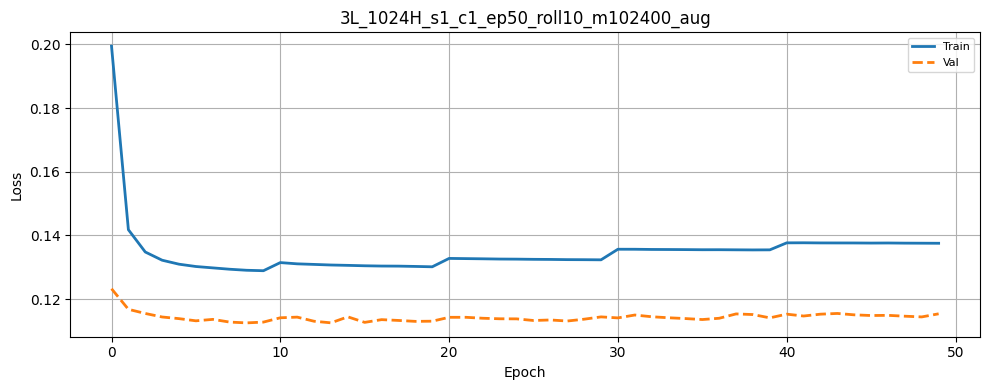

In [ ]:
import matplotlib.pyplot as plt

num_conditions = len(results)

fig, axes = plt.subplots(
    nrows=num_conditions,
    ncols=1,
    figsize=(10, 4 * num_conditions),
    sharex=True
)

# 조건이 1개일 때 axes가 list가 아니라 단일 객체가 되는 것 방지
if num_conditions == 1:
    axes = [axes]

for ax, (setting_name, result) in zip(axes, results.items()):
    ax.plot(result['train_loss'], label="Train", linewidth=2)
    ax.plot(result['val_loss'], linestyle='--', label="Val", linewidth=2)

    ax.set_title(setting_name)
    ax.set_ylabel("Loss")
    ax.grid(True)
    ax.legend(fontsize=8)

axes[-1].set_xlabel("Epoch")

plt.tight_layout()
plt.show()


In [ ]:
import os
import csv

# ==================================================
# CSV save path
# ==================================================
save_dir = "/home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift"
os.makedirs(save_dir, exist_ok=True)

csv_path = os.path.join(save_dir, "loss_curves_3L_1024H_s1_c3_shift.csv")

# ==================================================
# Write CSV
# ==================================================
with open(csv_path, "w", newline="") as f:
    writer = csv.DictWriter(
        f,
        fieldnames=[
            "setting_name",
            "epoch",
            "train_total_loss",
            "val_total_loss",
            "train_tracking_loss",
            "val_tracking_loss",
            "train_smooth_loss",
            "val_smooth_loss",
            "train_constraint_loss",
            "val_constraint_loss",
        ]
    )
    writer.writeheader()

    for setting_name, result in results.items():
        num_epoch = len(result["train_loss"])

        for epoch in range(num_epoch):
            writer.writerow({
                "setting_name": setting_name,
                "epoch": epoch + 1,
                "train_total_loss": result["train_loss"][epoch],
                "val_total_loss": result["val_loss"][epoch],
                "train_tracking_loss": result["train_tracking_loss"][epoch],
                "val_tracking_loss": result["val_tracking_loss"][epoch],
                "train_smooth_loss": result["train_smooth_loss"][epoch],
                "val_smooth_loss": result["val_smooth_loss"][epoch],
                "train_constraint_loss": result["train_constraint_loss"][epoch],
                "val_constraint_loss": result["val_constraint_loss"][epoch],
            })

print(f"[CSV] Saved loss curves to: {csv_path}")


[CSV] Saved loss curves to: /home/ftk3187/github/DPC_research/02_DED/6_policy_0108/experiments/baseline_shift/loss_curves_3L_1024H_s1_c3_shift.csv
